In [ ]:
# Install required packages (if not already installed)
!pip install -q tensorflow scikit-learn seaborn

In [ ]:
import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 6_Soiltypes(600).zip to 6_Soiltypes(600).zip


In [ ]:
import shutil
import os

if os.path.exists("/content/soil_dataset"):
    shutil.rmtree("/content/soil_dataset")

print("Deleted")

Deleted


In [ ]:
zip_file = list(uploaded.keys())[0]

extract_path = "/content/soil_dataset/6_Soiltypes(600)"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [ ]:
print(os.listdir(extract_path))

['6_Soiltypes(600)', 'Alluvial soil', 'Black soil', 'Sandy soil', 'Loamy soil', 'Slit soil', 'Clay soil']


In [ ]:
import os
import shutil

nested_folder = "/content/soil_dataset/6_Soiltypes(600)/6_Soiltypes(600)"

if os.path.exists(nested_folder):
    shutil.rmtree(nested_folder)
    print("Nested folder deleted successfully.")
else:
    print("No nested folder found.")

Nested folder deleted successfully.


In [ ]:
print(os.listdir("/content/soil_dataset/6_Soiltypes(600)"))

['Alluvial soil', 'Black soil', 'Sandy soil', 'Loamy soil', 'Slit soil', 'Clay soil']


In [ ]:
import os

for folder in sorted(os.listdir("/content/soil_dataset/6_Soiltypes(600)")):

    folder_path = os.path.join("/content/soil_dataset/6_Soiltypes(600)", folder)

    count = 0

    for root, dirs, files in os.walk(folder_path):
        count += len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))])

    print(f"{folder}: {count}")

Alluvial soil: 600
Black soil: 600
Clay soil: 600
Loamy soil: 600
Sandy soil: 600
Slit soil: 600


In [ ]:
class_names = []

image_count = {}

for folder in os.listdir(extract_path):

    folder_path = os.path.join(extract_path, folder)

    if os.path.isdir(folder_path):

        total = 0

        for root, dirs, files in os.walk(folder_path):

            total += len([
                file for file in files
                if file.lower().endswith(('.jpg','.jpeg','.png'))
            ])

        class_names.append(folder)
        image_count[folder] = total

print(image_count)

{'Alluvial soil': 600, 'Black soil': 600, 'Sandy soil': 600, 'Loamy soil': 600, 'Slit soil': 600, 'Clay soil': 600}


In [ ]:
df = pd.DataFrame(
    image_count.items(),
    columns=["Soil Type","Number of Images"]
)

df

,Soil Type,Number of Images
0,Alluvial soil,600
1,Black soil,600
2,Sandy soil,600
3,Loamy soil,600
4,Slit soil,600
5,Clay soil,600


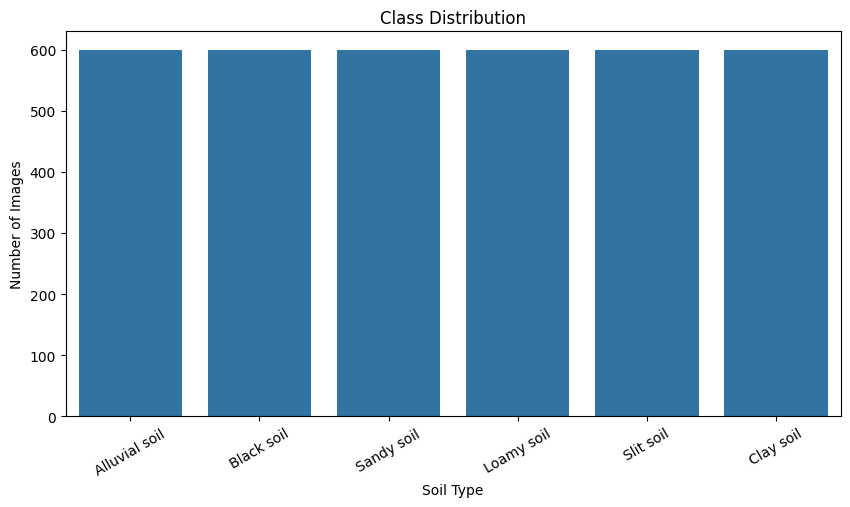

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Soil Type",
    y="Number of Images"
)

plt.xticks(rotation=30)

plt.title("Class Distribution")

plt.show()

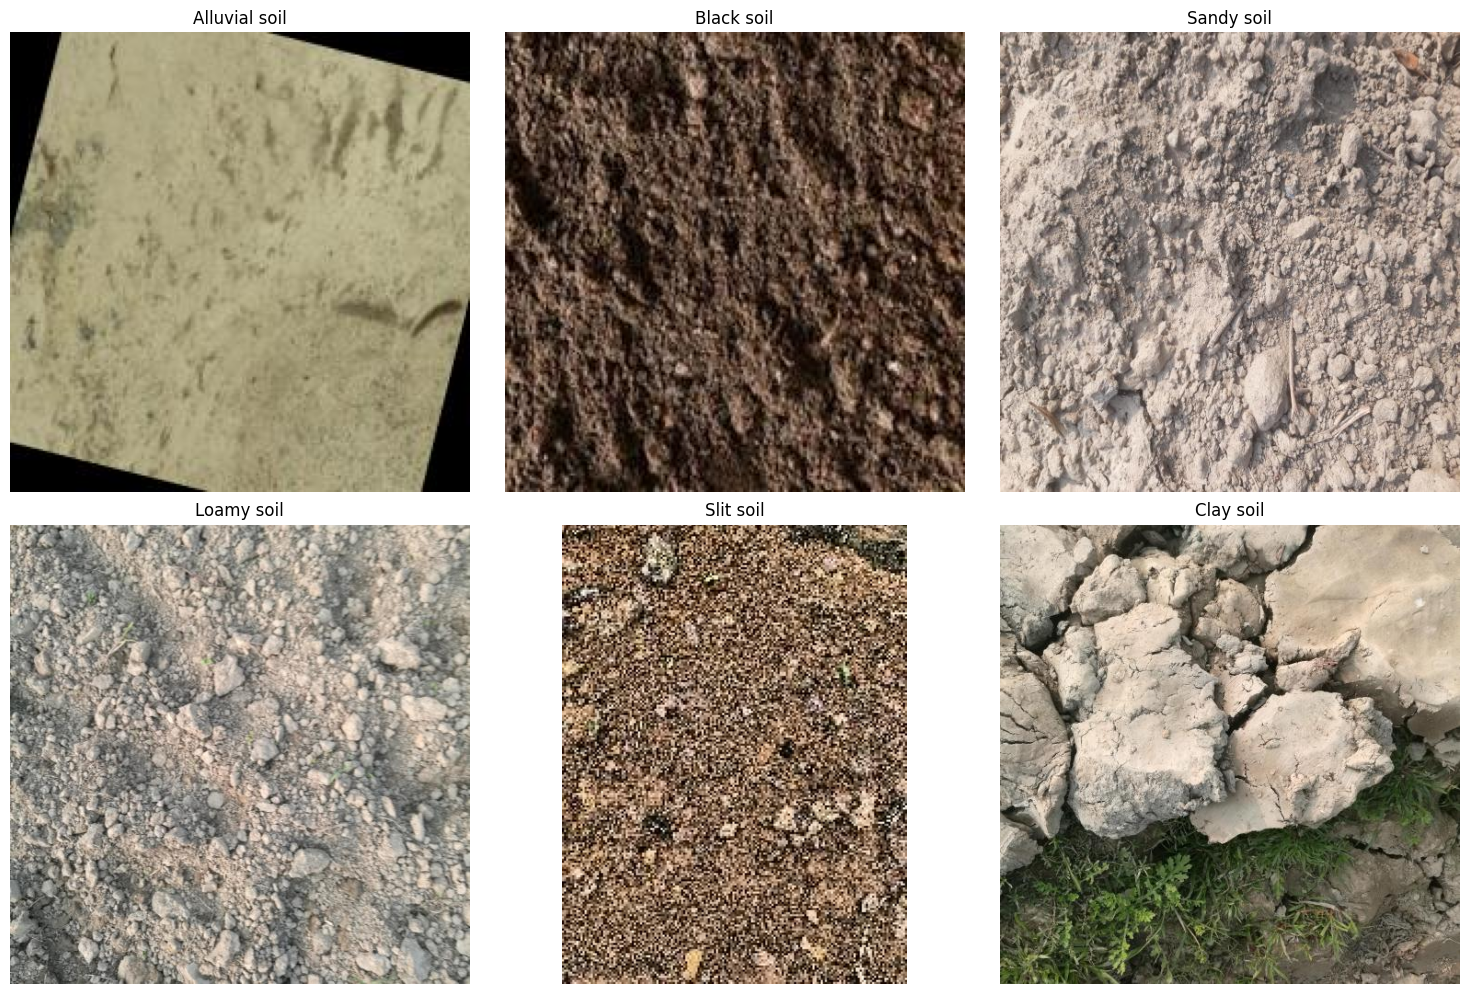

In [ ]:
plt.figure(figsize=(15,10))

index = 1

for soil in class_names:

    folder_path = os.path.join(extract_path, soil)

    image_files = []

    for root, dirs, files in os.walk(folder_path):

        for file in files:

            if file.lower().endswith((".jpg",".png",".jpeg")):

                image_files.append(os.path.join(root,file))

    image_path = random.choice(image_files)

    image = plt.imread(image_path)

    plt.subplot(2,3,index)

    plt.imshow(image)

    plt.title(soil)

    plt.axis("off")

    index += 1

plt.tight_layout()

plt.show()

In [ ]:
import os
import pandas as pd

# Lists to store image paths and labels
image_paths = []
labels = []

# Supported image formats
image_extensions = ('.jpg', '.jpeg', '.png')

# Traverse each class folder
for class_name in os.listdir(extract_path):

    class_path = os.path.join(extract_path, class_name)

    if os.path.isdir(class_path):

        for root, dirs, files in os.walk(class_path):

            for file in files:

                if file.lower().endswith(image_extensions):

                    image_paths.append(os.path.join(root, file))
                    labels.append(class_name)

# Create DataFrame
df = pd.DataFrame({
    'filepath': image_paths,
    'label': labels
})

print("Total Images:", len(df))
df.head()

Total Images: 3600


,filepath,label
0,/content/soil_dataset/6_Soiltypes(600)/Alluvia...,Alluvial soil
1,/content/soil_dataset/6_Soiltypes(600)/Alluvia...,Alluvial soil
2,/content/soil_dataset/6_Soiltypes(600)/Alluvia...,Alluvial soil
3,/content/soil_dataset/6_Soiltypes(600)/Alluvia...,Alluvial soil
4,/content/soil_dataset/6_Soiltypes(600)/Alluvia...,Alluvial soil


In [ ]:
print(df['label'].value_counts())

label
Alluvial soil    600
Black soil       600
Sandy soil       600
Loamy soil       600
Slit soil        600
Clay soil        600
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Train = 70%
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

# Validation = 15%, Test = 15%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Training Images :", len(train_df))
print("Validation Images :", len(val_df))
print("Testing Images :", len(test_df))

Training Images : 2520
Validation Images : 540
Testing Images : 540


In [ ]:
print("Training Set")
print(train_df['label'].value_counts())

print("\nValidation Set")
print(val_df['label'].value_counts())

print("\nTesting Set")
print(test_df['label'].value_counts())

Training Set
label
Alluvial soil    420
Sandy soil       420
Black soil       420
Loamy soil       420
Slit soil        420
Clay soil        420
Name: count, dtype: int64

Validation Set
label
Alluvial soil    90
Sandy soil       90
Slit soil        90
Clay soil        90
Black soil       90
Loamy soil       90
Name: count, dtype: int64

Testing Set
label
Loamy soil       90
Sandy soil       90
Slit soil        90
Alluvial soil    90
Clay soil        90
Black soil       90
Name: count, dtype: int64


In [ ]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
class_names = sorted(df['label'].unique())

label_to_index = {
    label: index
    for index, label in enumerate(class_names)
}

index_to_label = {
    index: label
    for label, index in label_to_index.items()
}

print(label_to_index)

{'Alluvial soil': 0, 'Black soil': 1, 'Clay soil': 2, 'Loamy soil': 3, 'Sandy soil': 4, 'Slit soil': 5}


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def preprocess_image(filepath, label):

    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, (224, 224))

    image = tf.cast(image, tf.float32)

    image = preprocess_input(image)

    return image, label

In [ ]:
train_labels = train_df['label'].map(label_to_index)
val_labels = val_df['label'].map(label_to_index)
test_labels = test_df['label'].map(label_to_index)

In [ ]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2),

    layers.RandomBrightness(0.2)

])

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_labels.values)
)

train_ds = train_ds.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.shuffle(1000)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(AUTOTUNE)

In [ ]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["filepath"].values,
        val_labels.values
    )
)

val_ds = val_ds.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE)

val_ds = val_ds.prefetch(AUTOTUNE)

In [ ]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["filepath"].values,
        test_labels.values
    )
)

test_ds = test_ds.map(
    preprocess_image,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)

test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
for images, labels in train_ds.take(1):

    print("Image Batch Shape :", images.shape)

    print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


In [ ]:
for images, labels in val_ds.take(1):
    print("Validation Images :", images.shape)
    print("Validation Labels :", labels.shape)

Validation Images : (32, 224, 224, 3)
Validation Labels : (32,)


In [ ]:
for images, labels in test_ds.take(1):
    print("Test Images :", images.shape)
    print("Test Labels :", labels.shape)

Test Images : (32, 224, 224, 3)
Test Labels : (32,)


In [ ]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(tf.reduce_min(images).numpy())
    print(tf.reduce_max(images).numpy())

(32, 224, 224, 3)
0.0
255.0


In [ ]:
sample_path = train_df.iloc[0]["filepath"]

image = tf.io.read_file(sample_path)
image = tf.image.decode_jpeg(image, channels=3)
image = tf.image.resize(image, (224,224))
image = tf.cast(image, tf.float32)

print("Before preprocessing")
print(tf.reduce_min(image).numpy())
print(tf.reduce_max(image).numpy())

image = preprocess_input(image)

print("\nAfter preprocessing")
print(tf.reduce_min(image).numpy())
print(tf.reduce_max(image).numpy())

Before preprocessing
0.0
255.0

After preprocessing
0.0
255.0


In [ ]:
from tensorflow.keras.applications import EfficientNetB0

# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all pretrained layers
base_model.trainable = False

print("EfficientNetB0 loaded successfully!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 loaded successfully!


In [ ]:
from tensorflow.keras import layers, Model

# Build classification head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(
    256,
    activation='relu'
)(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(
    6,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=0.0001
)

model.compile(

    optimizer=optimizer,

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[

        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')

    ]

)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True,

    verbose=1

)

checkpoint = ModelCheckpoint(

    filepath="best_efficientnetb0.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=5,

    min_lr=1e-6,

    verbose=1

)

In [ ]:
EPOCHS = 50

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=[


        checkpoint,

        reduce_lr

    ],

    verbose=1

)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.3789 - loss: 1.5728
Epoch 1: val_accuracy improved from None to 0.82407, saving model to best_efficientnetb0.keras

Epoch 1: finished saving model to best_efficientnetb0.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 104s 801ms/step - accuracy: 0.5405 - loss: 1.3061 - val_accuracy: 0.8241 - val_loss: 0.7841 - learning_rate: 1.0000e-04
Epoch 2/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.7901 - loss: 0.7963
Epoch 2: val_accuracy improved from 0.82407 to 0.89444, saving model to best_efficientnetb0.keras

Epoch 2: finished saving model to best_efficientnetb0.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 274ms/step - accuracy: 0.8218 - loss: 0.6936 - val_accuracy: 0.8944 - val_loss: 0.4602 - learning_rate: 1.0000e-04
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.8734 - loss: 0.4947
Epoch 3: val_accuracy improved from 0.89444 to 0.92778, saving model to best_efficientnetb0.keras

Epoch 3: finished saving model to b

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9722 - loss: 0.0689
Test Loss     : 0.0689
Test Accuracy : 97.22%


In [ ]:
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(test_ds)

# Predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 430ms/step


In [ ]:
y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.9725
Recall    : 0.9722
F1 Score  : 0.9721


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

               precision    recall  f1-score   support

Alluvial soil       0.98      0.93      0.95        90
   Black soil       0.96      0.94      0.95        90
    Clay soil       0.97      1.00      0.98        90
   Loamy soil       1.00      0.98      0.99        90
   Sandy soil       0.98      0.98      0.98        90
    Slit soil       0.96      1.00      0.98        90

     accuracy                           0.97       540
    macro avg       0.97      0.97      0.97       540
 weighted avg       0.97      0.97      0.97       540



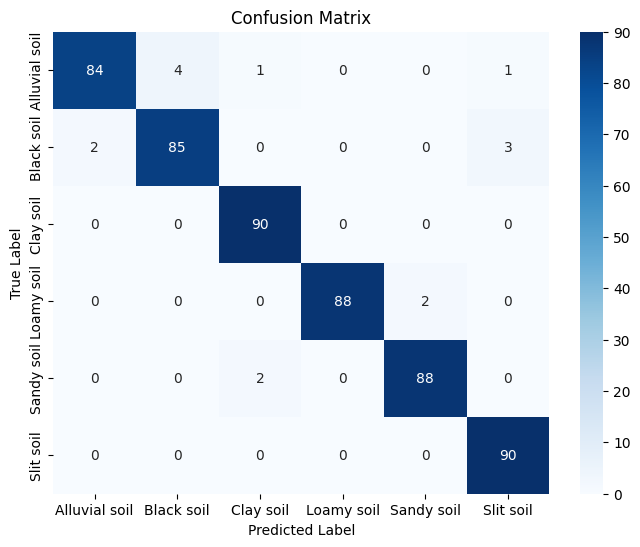

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

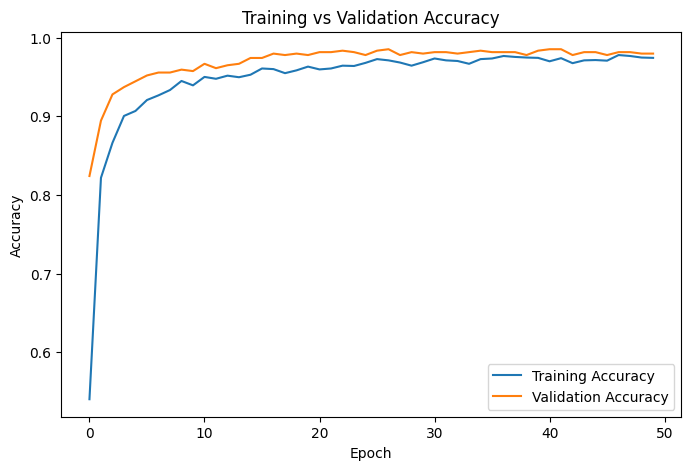

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

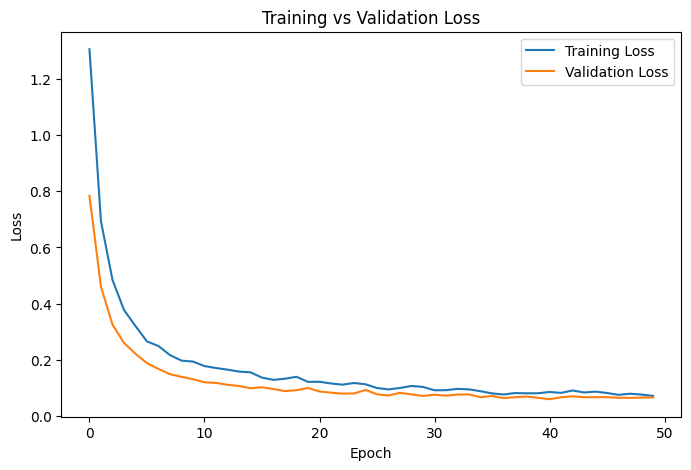

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


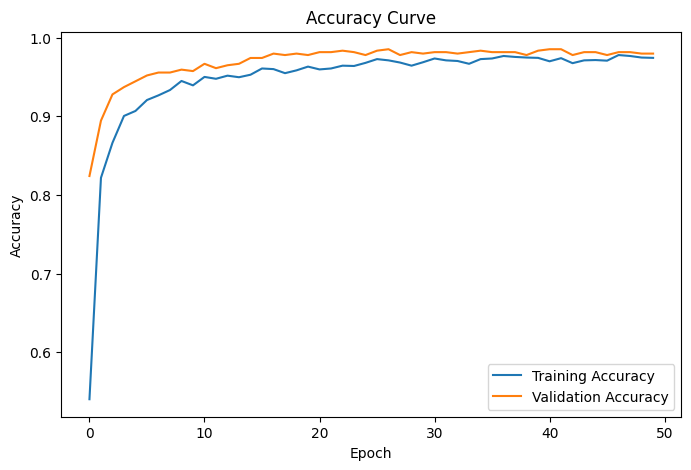

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()

plt.show()

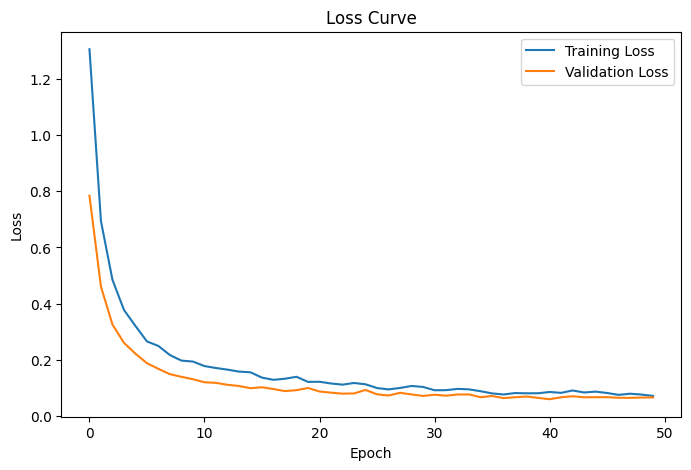

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

plt.show()

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'soil_dataset', '6_Soiltypes(600).zip', 'best_efficientnetb0.keras', 'sample_data']


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_efficientnetb0.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving aug_118_IMG_20250113_173305_jpg.rf.33f0e162d0f3fa1f3841c6c793447c49.jpg to aug_118_IMG_20250113_173305_jpg.rf.33f0e162d0f3fa1f3841c6c793447c49.jpg


In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np

image_path = list(uploaded.keys())[0]

img = image.load_img(
    image_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

In [ ]:
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

print("Predicted Soil Type :", class_names[predicted_class])
print(f"Confidence : {confidence*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Predicted Soil Type : Clay soil
Confidence : 100.00%


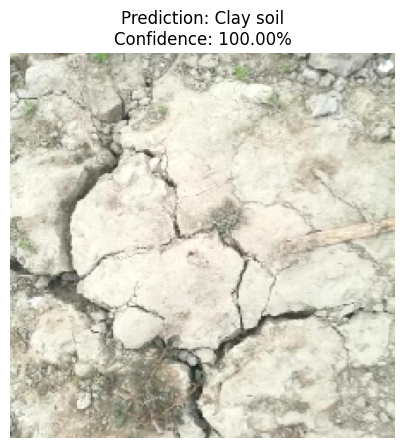

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.imshow(img)

plt.title(
    f"Prediction: {class_names[predicted_class]}\nConfidence: {confidence*100:.2f}%"
)

plt.axis("off")

plt.show()

In [ ]:
print("\nPrediction Probabilities:\n")

for soil, prob in zip(class_names, prediction[0]):
    print(f"{soil:<15}: {prob*100:.2f}%")


Prediction Probabilities:

Alluvial soil  : 0.00%
Black soil     : 0.00%
Clay soil      : 100.00%
Loamy soil     : 0.00%
Sandy soil     : 0.00%
Slit soil      : 0.00%
